In [1]:
import sys
import os

sys.path.append(os.path.abspath(".."))

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from src.preprocessing import preprocess_text

In [3]:
import pandas as pd

df = pd.read_csv("../data/UpdatedResumeDataSet.csv")

In [4]:
df.head()

,Category,Resume
0,Data Science,Skills * Programming Languages: Python (pandas...
1,Data Science,Education Details \r\nMay 2013 to May 2017 B.E...
2,Data Science,"Areas of Interest Deep Learning, Control Syste..."
3,Data Science,Skills â¢ R â¢ Python â¢ SAP HANA â¢ Table...
4,Data Science,"Education Details \r\n MCA YMCAUST, Faridab..."


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 962 entries, 0 to 961
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   Category  962 non-null    str  
 1   Resume    962 non-null    str  
dtypes: str(2)
memory usage: 15.2 KB


In [6]:
df.shape

(962, 2)

In [7]:
df.columns

Index(['Category', 'Resume'], dtype='str')

In [8]:
df["Category"].value_counts()

Category
Java Developer               84
Testing                      70
DevOps Engineer              55
Python Developer             48
Web Designing                45
HR                           44
Hadoop                       42
Data Science                 40
Mechanical Engineer          40
Sales                        40
Operations Manager           40
ETL Developer                40
Blockchain                   40
Arts                         36
Database                     33
Health and fitness           30
Electrical Engineering       30
PMO                          30
Business Analyst             28
DotNet Developer             28
Automation Testing           26
Network Security Engineer    25
Civil Engineer               24
SAP Developer                24
Advocate                     20
Name: count, dtype: int64

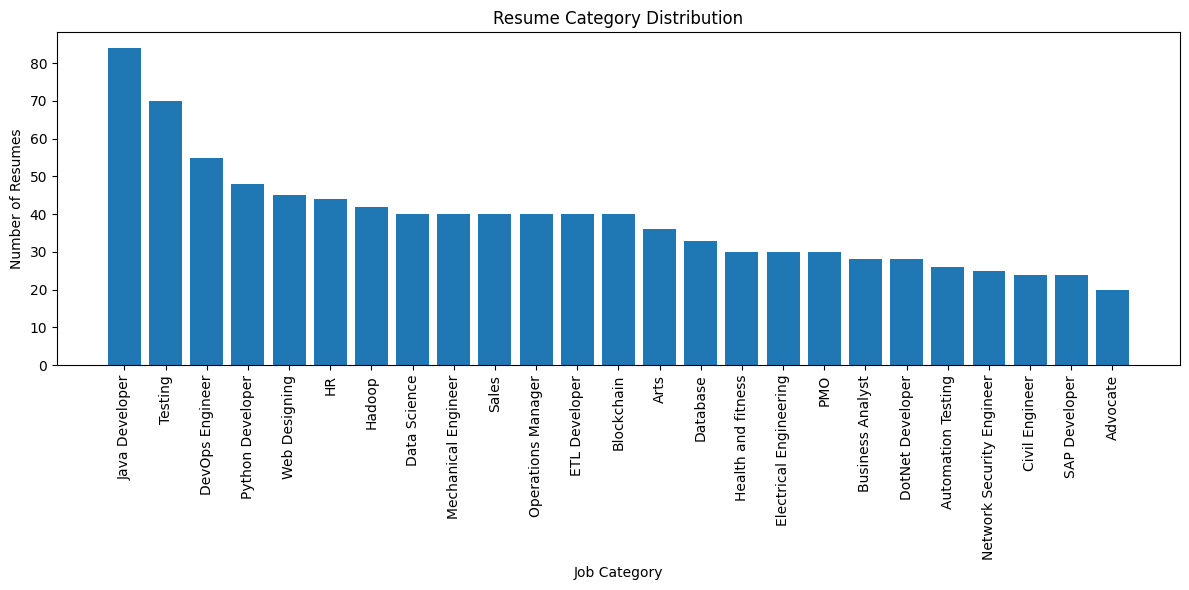

In [9]:
import matplotlib.pyplot as plt

category_counts = df["Category"].value_counts()

plt.figure(figsize=(12, 6))
plt.bar(category_counts.index, category_counts.values)

plt.xticks(rotation=90)
plt.xlabel("Job Category")
plt.ylabel("Number of Resumes")
plt.title("Resume Category Distribution")

plt.tight_layout()
plt.show()

In [10]:
df.isnull().sum()

Category    0
Resume      0
dtype: int64

In [11]:
df["Cleaned_Resume"] = df["Resume"].apply(preprocess_text)